<a href="https://colab.research.google.com/github/ris2002/AI_python/blob/main/Adult_Census_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("uciml/adult-census-income")
file_path = os.path.join(path, "adult.csv")

print("Path to dataset files:", file_path)

Using Colab cache for faster access to the 'adult-census-income' dataset.
Path to dataset files: /kaggle/input/adult-census-income/adult.csv


Basic EDA

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
# We can see NAN values are rep with '?'. Now replace '?' with NAN and count total NAN val
df.replace('?',np.nan,inplace=True)
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
#We can see that around 2k rrows have null values about 6%. By decission is to scrap these null rows as my feeling is that NN needss to be fed with quality data and the quantity is enough to train it
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 1 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education.num   30162 non-null  int64 
 5   marital.status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital.gain    30162 non-null  int64 
 11  capital.loss    30162 non-null  int64 
 12  hours.per.week  30162 non-null  int64 
 13  native.country  30162 non-null  object
 14  income          30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
X=df.drop(columns=['income','fnlwgt'])
y=df['income']
#Dropping fnlwgt because it is ot the feature attributeed to an individual it is the for a whole group


In [ ]:
categorical_features=[]
numerical_features=['age','education.num', 'hours.per.week','capital.loss','capital.gain']
all_feature_names=X.columns.tolist()
for col in all_feature_names:
  if col not in numerical_features:
    categorical_features.append(col)
categorical_features


['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

In [ ]:
df[numerical_features].describe()

,age,education.num,hours.per.week,capital.loss,capital.gain
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,10.121312,40.931238,88.372489,1092.007858
std,13.134665,2.549995,11.979984,404.298370,7406.346497
min,17.000000,1.000000,1.000000,0.000000,0.000000
25%,28.000000,9.000000,40.000000,0.000000,0.000000
50%,37.000000,10.000000,40.000000,0.000000,0.000000
75%,47.000000,13.000000,45.000000,0.000000,0.000000
max,90.000000,16.000000,99.000000,4356.000000,99999.000000


EDA Step-1: Distribution Analysis Of numerical Features

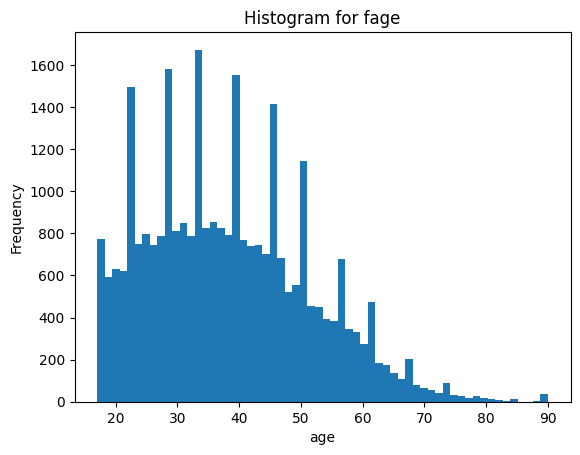

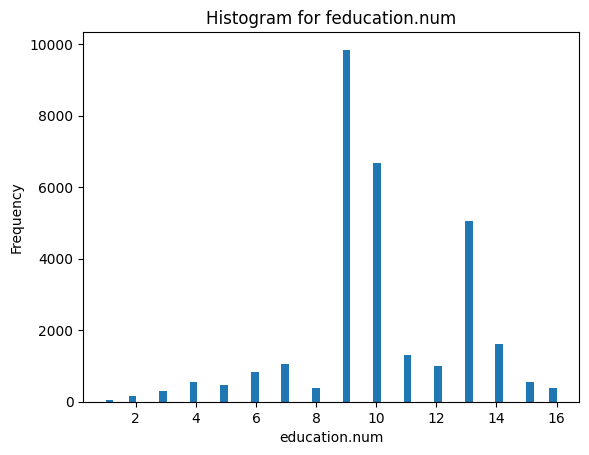

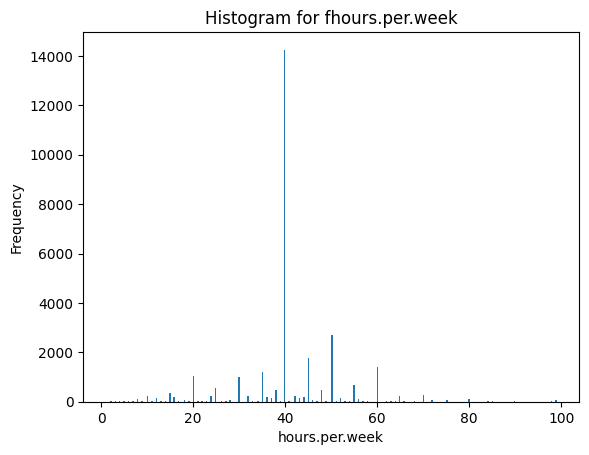

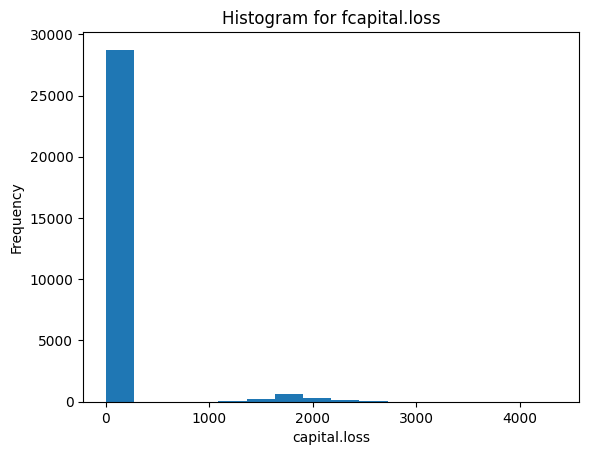

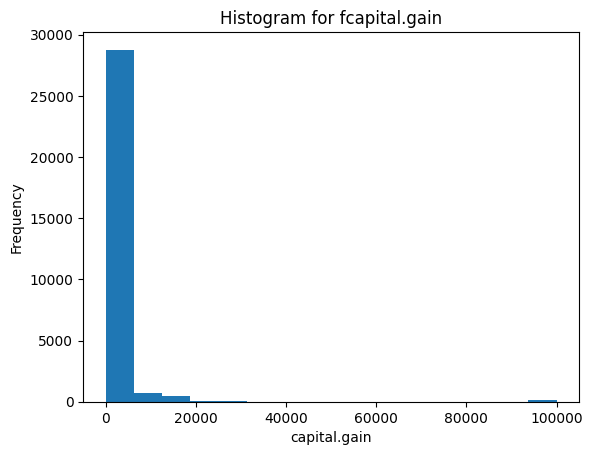

In [ ]:
import matplotlib.pyplot as plt
for col in numerical_features:
  plt.figure()
  plt.hist(X[col], bins='auto')
  plt.title(f'Histogram for f{col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

In [ ]:
# from above we can see all the graphs are mostly right skewed annd there is a visible amount of outliers and the distributions are highly imbalanced and not normally distributed.
# From above graphs we see that majority of the frequecy of capital loss ad gainn is 0 for this we do it in the next step whhich is zero iflated values

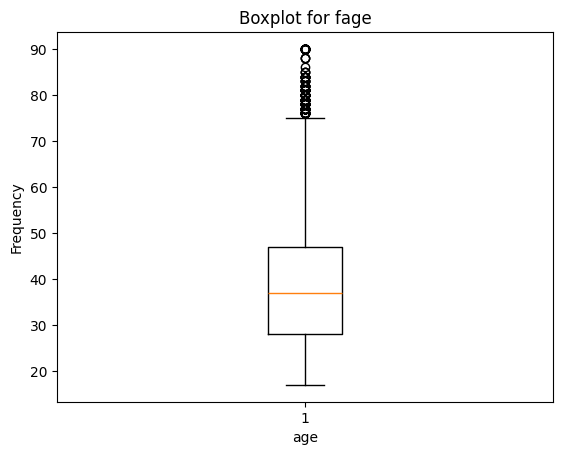

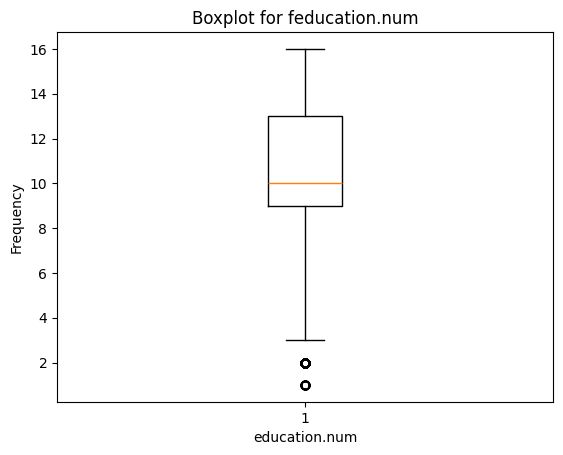

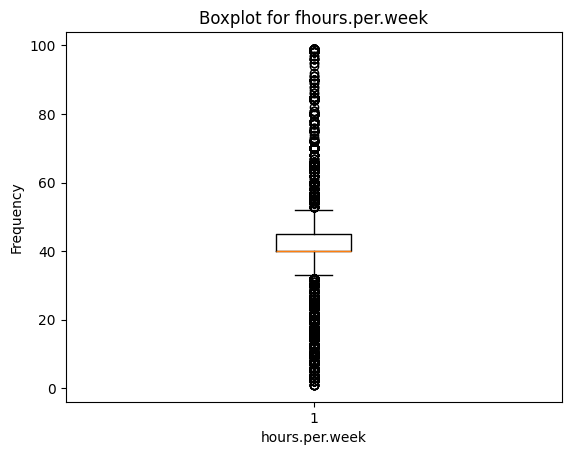

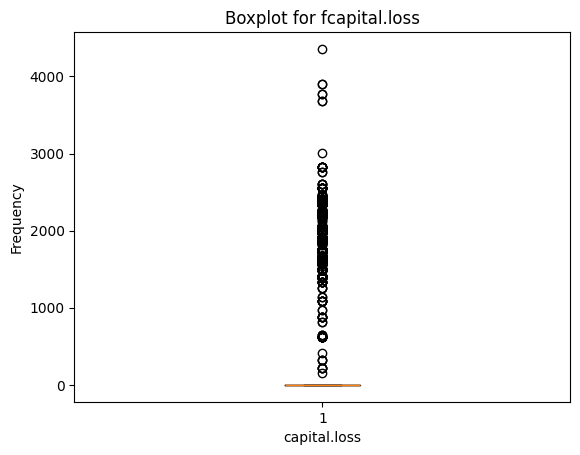

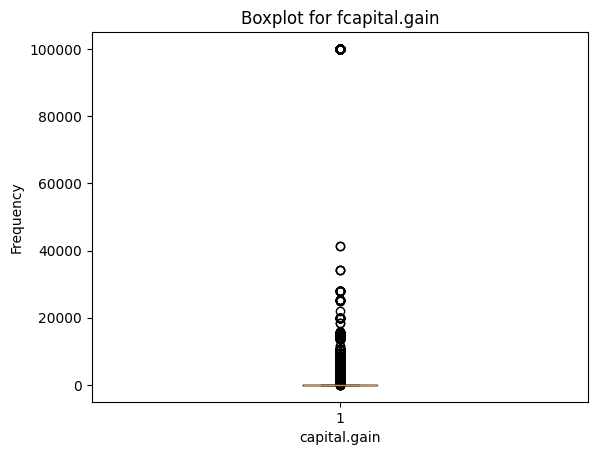

In [ ]:
import matplotlib.pyplot as plt
for col in numerical_features:
  plt.figure()
  plt.boxplot(X[col])
  plt.title(f'Boxplot for f{col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

In [ ]:
'''
Box Plot Interpretation-https://www.geeksforgeeks.org/data-visualization/box-plot-in-python-using-matplotlib/
Conclusions from the box plot-
* For Age Box plot  we can see that-
  The box is bigger suggesting high variabilty
  The box is slightly lower with lonnger whisker suggesting right skewness and there some outliers
  My decision on this particular feature is that- no transformation is required because it is a important deature in adult census dataset and transforming this data might disrupt the predictive results of NN and ML model
* For capital.gain and capial.loss we can see that the boxplots are heavively right skewed and concentrated on 0 annd there are too many outliers.
  My decision for these features is to apply log transformatios and create 2 new col which rep thhe binary version of the data
* For hours boxplot there is less skewness so no log transformations are required to handle the skewness, but outliers must be handled as there are so many outliers
* I feel this is little ideal boxplot ,it is little left skewed but not to an extreme and there are less outlieres so no change to the data

'''

'\nBox Plot Interpretation-https://www.geeksforgeeks.org/data-visualization/box-plot-in-python-using-matplotlib/\nConclusions from the box plot-\n* For Age Box plot  we can see that-\n  The box is bigger suggesting high variabilty\n  The box is slightly lower with lonnger whisker suggesting right skewness and there some outliers\n  My decision on this particular feature is that- no transformation is required because it is a important deature in adult census dataset and transforming this data might disrupt the predictive results of NN and ML model\n* For capital.gain and capial.loss we can see that the boxplots are heavively right skewed and concentrated on 0 annd there are too many outliers.\n  My decision for these features is to apply log transformatios and create 2 new col which rep thhe binary version of the data\n* For hours boxplot there is less skewness so no log transformations are required to handle the skewness, but outliers must be handled as there are so many outliers\n* I 

In [ ]:
X['capital.gain']=np.log1p(X['capital.gain'])
X['capital.loss']=np.log1p(X['capital.loss'])

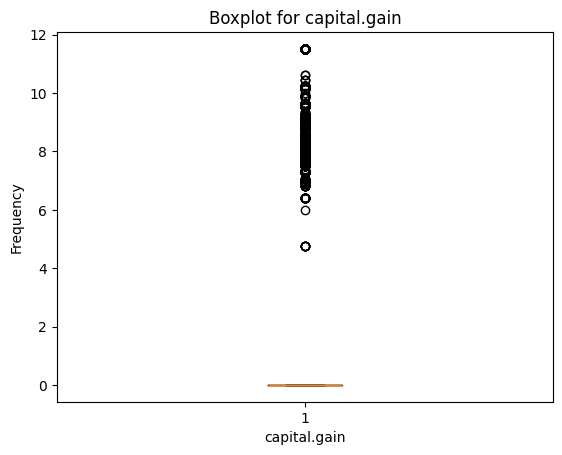

In [ ]:
plt.figure()
plt.boxplot(X['capital.gain'])
plt.title(f'Boxplot for capital.gain')
plt.xlabel('capital.gain')
plt.ylabel('Frequency')
plt.show()

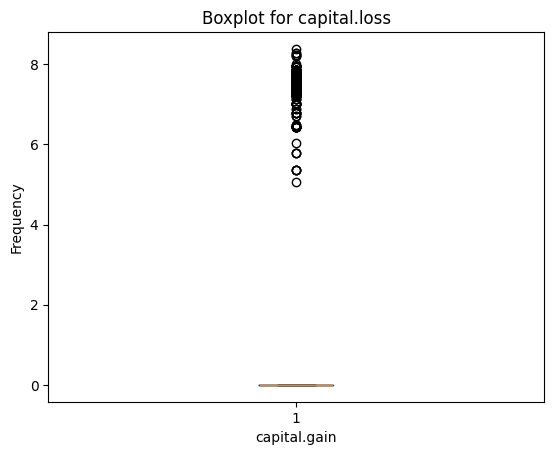

In [ ]:
plt.figure()
plt.boxplot(X['capital.loss'])
plt.title(f'Boxplot for capital.loss')
plt.xlabel('capital.gain')
plt.ylabel('Frequency')
plt.show()

In [ ]:
'''
Conclusions gained from log transformations we can see taht even though visually there is o=nno channge notice on the y-axis, thhe outliers which were large amount of data has been reduced to small countable size there by reducing the right-skewness
'''

'\nConclusions gained from log transformations \n'

In [ ]:
X['has_capital_gain']=np.where(X['capital.gain']>0,1,0)
X['has_capital_loss']=np.where(X['capital.loss']>0,1,0)

In [ ]:
X.shape

(30162, 15)

In [ ]:
X.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,has_capital_gain,has_capital_loss
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0.0,8.379539,18,United-States,0,1
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0.0,8.268988,40,United-States,0,1
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0.0,8.268988,40,United-States,0,1
5,34,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0.0,8.235095,45,United-States,0,1
6,38,Private,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0.0,8.235095,40,United-States,0,1


Exploring Categorical Data

In [ ]:
for col in categorical_features:
  print(f'the col name is {col},{X[col].value_counts()}')

the col name is workclass,workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64
the col name is education,education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          288
1st-4th          151
Preschool         45
Name: count, dtype: int64
the col name is marital.status,marital.status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64
the col name is occupation,occupation
Prof-specialty       4038
Craft

SMOTE Resampling,Encoding and scaling

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,RobustScaler,LabelEncoder,OrdinalEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split

In [ ]:
smote=SMOTENC(categorical_features=categorical_features,random_state=4)

In [ ]:
x_train_temp,x_test,y_train_temp,y_test=train_test_split(X,y,random_state=6,test_size=0.1)

In [ ]:
x_train_sm,y_train_sm=smote.fit_resample(x_train_temp,y_train_temp)

In [ ]:
x_train_sm.shape

(40816, 15)

In [ ]:
y_train_sm.shape

(40816,)

In [ ]:
nominal_data=[]
ordinal_data=[]
for col in categorical_features:
  if col=="education" or col=="occupation":
    ordinal_data.append(col)
  else:
    nominal_data.append(col)

In [ ]:
nominal_data

['workclass',
 'marital.status',
 'relationship',
 'race',
 'sex',
 'native.country']

In [ ]:
ordinal_data

['education', 'occupation']

In [ ]:
numerical_features.remove('education.num')
sd_feature=['education.num']

In [ ]:
col_transform=ColumnTransformer(transformers=[('OHE',OneHotEncoder(handle_unknown='ignore'),nominal_data),('OE',OrdinalEncoder(),ordinal_data),('Standard_Scalar',StandardScaler(),sd_feature),('RS',RobustScaler(),numerical_features)])

In [ ]:
le=LabelEncoder()
y_train=le.fit_transform(y_train_sm)

In [ ]:
x_train=col_transform.fit_transform(x_train_sm)